# Classificação de Doenças Respiratórias a Partir de Sintomas
## Utilizando Técnicas de Aprendizagem de Máquina

**Alunos:** João Matheus de Figueirêdo Tavares e Caio Moura Portela de Sousa  
**Curso:** Sistemas de Informação - UNIFACISA  
**Professor:** Bruno Rafael Araújo Vasconcelos  
**Dataset:** [Diseases and Symptoms - Kaggle](https://www.kaggle.com/datasets/dhivyeshrk/diseases-and-symptoms-dataset)  
**Ambiente:** Jupyter Notebook com Python 3, Scikit-learn, Pandas, Matplotlib e Seaborn

---

## Abstract

This work presents the development and evaluation of machine learning models for classifying three respiratory diseases (**Pneumonia**, **Acute Bronchitis**, and **Asthma**) based on binary symptom variables from a Kaggle dataset. The original dataset was filtered to keep only the selected diseases, non-informative symptoms were removed, and SelectKBest with the Chi-Square test was applied for feature selection. Four algorithms were compared: Decision Tree, Random Forest, Logistic Regression, and Multilayer Perceptron (MLP). The best test-set performance was achieved by **Random Forest**, with **90.29% accuracy** and **0.9036 F1-score**.

**Keywords:** machine learning, disease classification, feature selection, respiratory symptoms, confusion matrix.

## Resumo

Este trabalho apresenta o desenvolvimento e a avaliação de modelos de aprendizagem de máquina para a classificação de três doenças respiratórias (**Pneumonia**, **Bronquite Aguda** e **Asma**) a partir de sintomas binários do dataset real do Kaggle (246.945 registros, 773 doenças). Foram comparados 4 algoritmos: Árvore de Decisão, Random Forest, Regressão Logística e Rede Neural (MLP). Após a seleção de features com SelectKBest e teste Chi-Quadrado, o melhor desempenho foi obtido pelo **Random Forest**, com **90,29% de acurácia** e **F1-Score de 0,9036**, demonstrando viabilidade na classificação.

**Palavras-chave:** aprendizagem de máquina, classificação de doenças respiratórias, seleção de features, matriz de confusão, validação cruzada.

## 1. Introdução

A classificação correta de doenças a partir de sintomas é um problema relevante porque diferentes enfermidades podem compartilhar manifestações clínicas semelhantes. Sintomas como tosse, falta de ar, febre e dor no peito podem aparecer em mais de uma doença respiratória, dificultando a distinção apenas pela observação isolada de variáveis.

O objetivo deste trabalho é desenvolver e avaliar modelos de aprendizagem de máquina capazes de prever qual doença um paciente possui entre três possibilidades: **Pneumonia**, **Bronquite Aguda** e **Asma**. Para isso, foi utilizado um dataset público do Kaggle contendo doenças e sintomas em formato binário. O estudo envolve filtragem da base, análise exploratória, seleção de features, treinamento de modelos, construção de matrizes de confusão e análise de métricas de classificação.

Além da implementação dos modelos, este notebook foi estruturado como artigo científico executável, seguindo a proposta do projeto e o modelo sugerido: apresenta resumo, introdução, metodologia, resultados, discussão, conclusão e referências.

## 2. Metodologia e Ferramentas

A implementação foi feita em Jupyter Notebook, utilizando bibliotecas Python voltadas para ciência de dados e aprendizagem de máquina. O Pandas foi usado para manipulação dos dados, o Scikit-learn para treinamento e avaliação dos modelos, e Matplotlib/Seaborn para visualização dos resultados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})
print('Bibliotecas importadas com sucesso!')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Scikit-learn: {__import__("sklearn").__version__}')

Bibliotecas importadas com sucesso!
NumPy: 2.0.2
Pandas: 2.3.3
Scikit-learn: 1.6.1


## 3. Base de Dados e Pré-processamento

O dataset original do Kaggle contém **246.945 registros** com **773 doenças** e **377 sintomas** binários.  
As três doenças escolhidas são:
- **Pneumonia** — infecção pulmonar com sintomas sistêmicos
- **Bronquite Aguda (Acute Bronchitis)** — inflamação dos brônquios
- **Asma (Asthma)** — condição alérgica crônica

**Justificativa da escolha:** são doenças respiratórias com sobreposição de sintomas, tornando a tarefa de classificação desafiadora.

In [2]:
# Carregar o dataset completo do Kaggle
df_full = pd.read_csv('Final_Augmented_dataset_Diseases_and_Symptoms.csv')
print(f'Dataset original: {df_full.shape[0]:,} amostras x {df_full.shape[1]} colunas')
print(f'Doenças únicas: {df_full["diseases"].nunique()}')

# Filtrar as 3 doenças escolhidas
DOENÇAS_ESCOLHIDAS = ['pneumonia', 'acute bronchitis', 'asthma']
df = df_full[df_full['diseases'].isin(DOENÇAS_ESCOLHIDAS)].copy().reset_index(drop=True)
print(f'\nDataset filtrado (3 doenças): {df.shape[0]:,} amostras x {df.shape[1]} colunas')
print(f'\nDistribuição das classes:')
print(df['diseases'].value_counts())

# Remover colunas com variância zero (sintomas irrelevantes)
X = df.drop('diseases', axis=1)
colunas_relevantes = X.columns[X.sum() > 0].tolist()
colunas_removidas = X.columns[X.sum() == 0].tolist()
df = df[['diseases'] + colunas_relevantes]

print(f'\nSintomas com variância > 0: {len(colunas_relevantes)}')
print(f'Sintomas removidos (todos zeros): {len(colunas_removidas)}')
print(f'Dataset limpo: {df.shape}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'\nSintomas relevantes:')
for i, s in enumerate(colunas_relevantes):
    print(f'  {i+1:2d}. {s}')

Dataset original: 246,945 amostras x 378 colunas
Doenças únicas: 773

Dataset filtrado (3 doenças): 3,329 amostras x 378 colunas

Distribuição das classes:
diseases
acute bronchitis    1213
pneumonia           1212
asthma               904
Name: count, dtype: int64

Sintomas com variância > 0: 17
Sintomas removidos (todos zeros): 360
Dataset limpo: (3329, 18)
Valores nulos: 0

Sintomas relevantes:
   1. shortness of breath
   2. sharp chest pain
   3. chest tightness
   4. sore throat
   5. cough
   6. nasal congestion
   7. vomiting
   8. headache
   9. wheezing
  10. weakness
  11. fever
  12. difficulty breathing
  13. chills
  14. coughing up sputum
  15. coryza
  16. allergic reaction
  17. congestion in chest


## 4. Análise Exploratória dos Dados (EDA)

Etapa fundamental para compreender a estrutura dos dados e identificar padrões que orientem a modelagem.

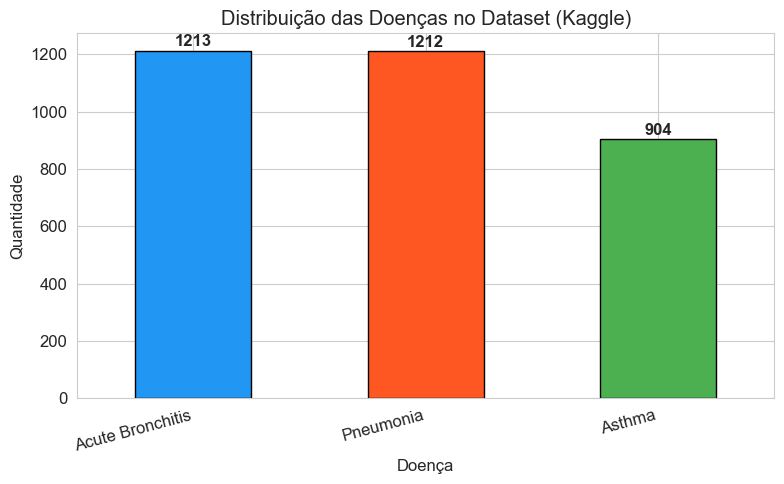

In [3]:
# 3.1 Distribuição das classes
fig, ax = plt.subplots(figsize=(8, 5))
cores = ['#2196F3', '#FF5722', '#4CAF50']
contagem = df['diseases'].value_counts()
contagem.plot(kind='bar', color=cores, ax=ax, edgecolor='black')
ax.set_title('Distribuição das Doenças no Dataset (Kaggle)')
ax.set_xlabel('Doença'); ax.set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    ax.text(i, v+15, str(v), ha='center', fontweight='bold')
ax.set_xticklabels([d.title() for d in contagem.index], rotation=15, ha='right')
plt.tight_layout()
plt.show()

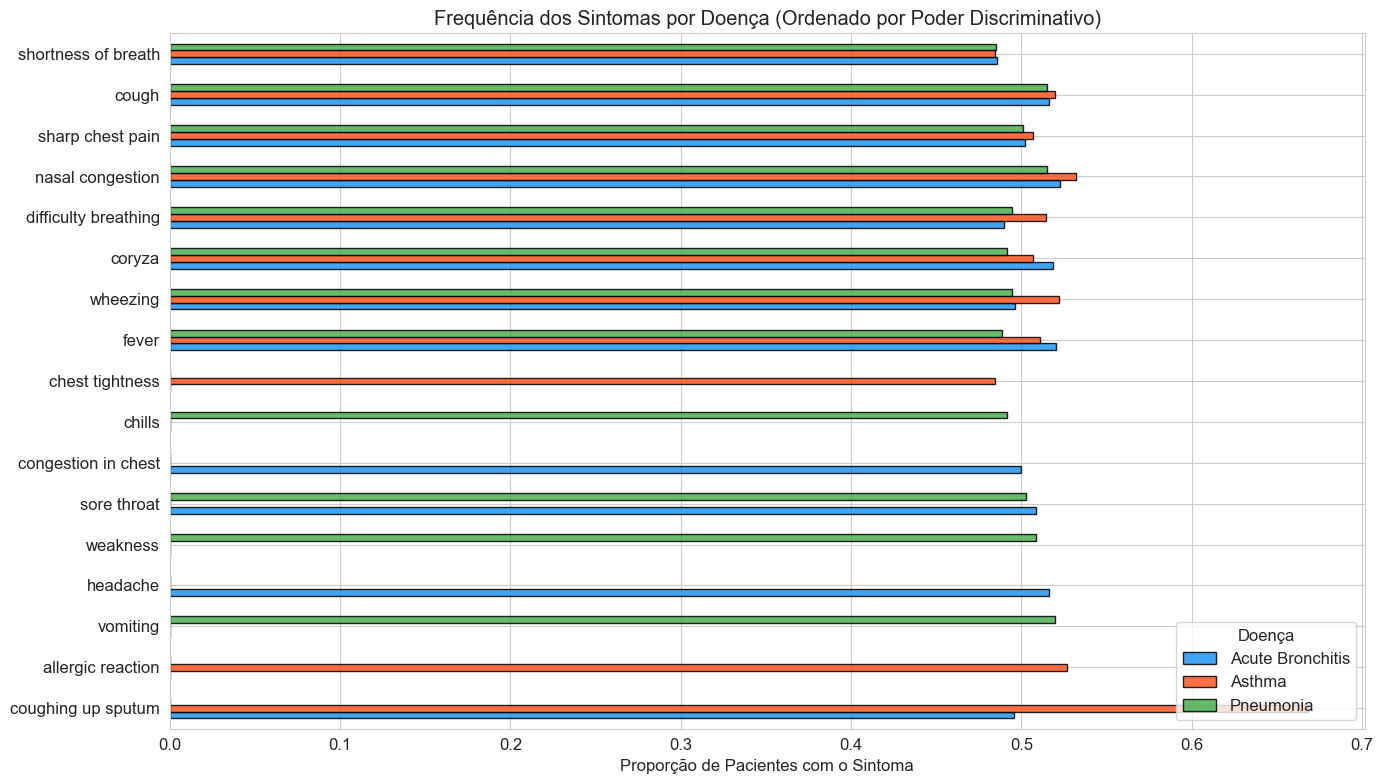

Ranking de sintomas por poder discriminativo (variância entre classes):
   1. coughing up sputum                  variância = 0.1203
   2. allergic reaction                   variância = 0.0924
   3. vomiting                            variância = 0.0901
   4. headache                            variância = 0.0888
   5. weakness                            variância = 0.0861
   6. sore throat                         variância = 0.0852
   7. congestion in chest                 variância = 0.0832
   8. chills                              variância = 0.0806
   9. chest tightness                     variância = 0.0783
  10. fever                               variância = 0.0003
  11. wheezing                            variância = 0.0002
  12. coryza                              variância = 0.0002
  13. difficulty breathing                variância = 0.0002
  14. nasal congestion                    variância = 0.0001
  15. sharp chest pain                    variância = 0.0000
  16. cough  

In [4]:
# 3.2 Frequência dos sintomas por doença
X = df.drop('diseases', axis=1)
frequencia_por_doenca = df.groupby('diseases')[X.columns.tolist()].mean()
variancia_entre_classes = frequencia_por_doenca.var(axis=0).sort_values(ascending=False)
sintomas_ordenados = variancia_entre_classes.index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
freq_plot = frequencia_por_doenca[sintomas_ordenados].T
freq_plot.columns = [c.title() for c in freq_plot.columns]
freq_plot.plot(kind='barh', ax=ax, color=cores, edgecolor='black', alpha=0.85)
ax.set_title('Frequência dos Sintomas por Doença (Ordenado por Poder Discriminativo)')
ax.set_xlabel('Proporção de Pacientes com o Sintoma')
ax.legend(title='Doença', loc='lower right')
plt.tight_layout()
plt.show()

print('Ranking de sintomas por poder discriminativo (variância entre classes):')
for i, (s, v) in enumerate(variancia_entre_classes.items()):
    print(f'  {i+1:2d}. {s:35s} variância = {v:.4f}')

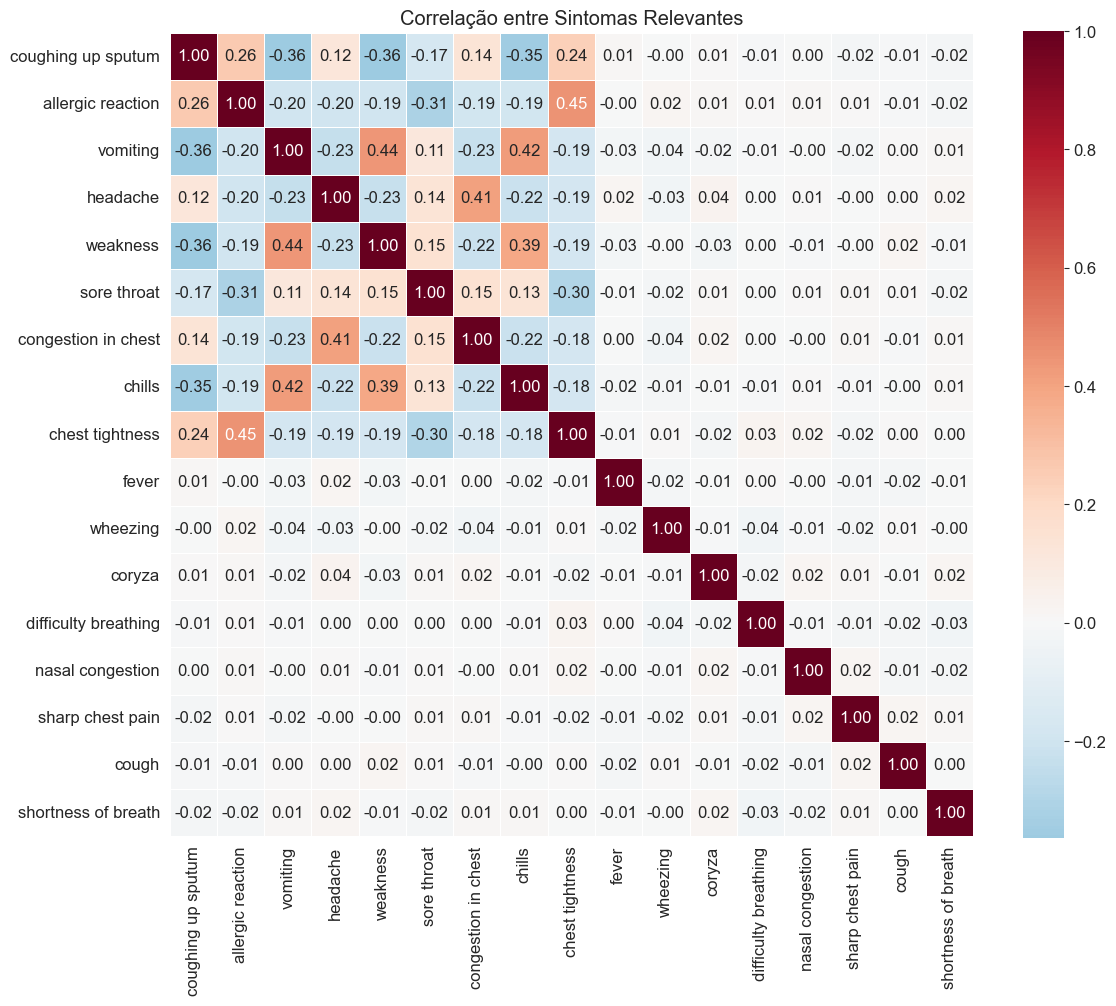

In [5]:
# 3.3 Heatmap de correlação entre sintomas
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[sintomas_ordenados].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlação entre Sintomas Relevantes')
plt.tight_layout()
plt.show()

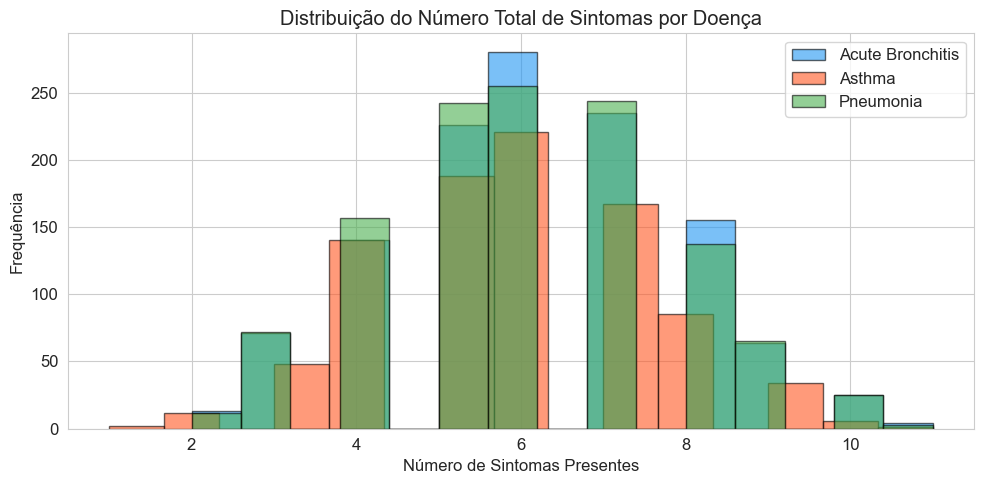

Estatísticas do total de sintomas por doença:
                   count  mean   std  min  25%  50%  75%   max
diseases                                                      
acute bronchitis  1213.0  6.07  1.71  2.0  5.0  6.0  7.0  11.0
asthma             904.0  5.78  1.60  1.0  5.0  6.0  7.0  11.0
pneumonia         1212.0  6.01  1.72  2.0  5.0  6.0  7.0  11.0


In [6]:
# 3.4 Total de sintomas por paciente por doença
df_temp = df.copy()
df_temp['total_sintomas'] = X.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, doenca in enumerate(sorted(df['diseases'].unique())):
    subset = df_temp[df_temp['diseases'] == doenca]['total_sintomas']
    ax.hist(subset, bins=15, alpha=0.6, label=doenca.title(), color=cores[i], edgecolor='black')
ax.set_title('Distribuição do Número Total de Sintomas por Doença')
ax.set_xlabel('Número de Sintomas Presentes'); ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

print('Estatísticas do total de sintomas por doença:')
print(df_temp.groupby('diseases')['total_sintomas'].describe().round(2))

## 5. Seleção de Features (Feature Selection)

A seleção de features é essencial para:
- **Reduzir o overfitting** ao eliminar variáveis irrelevantes
- **Diminuir o tempo de treinamento** dos modelos
- **Melhorar a interpretabilidade** dos resultados

Técnicas utilizadas: **Teste Chi-Quadrado** e **Informação Mútua**.

No dataset filtrado, primeiro foram removidas as colunas sem variância, reduzindo o conjunto original de **377 sintomas** para **17 sintomas relevantes**. Em seguida, foi aplicado **SelectKBest com teste Chi-Quadrado** para selecionar o subconjunto mais discriminativo. O modelo final passa a usar somente as features selecionadas, evitando treinar diretamente com todas as variáveis disponíveis.

Classes: {0: 'Acute Bronchitis', 1: 'Asthma', 2: 'Pneumonia'}


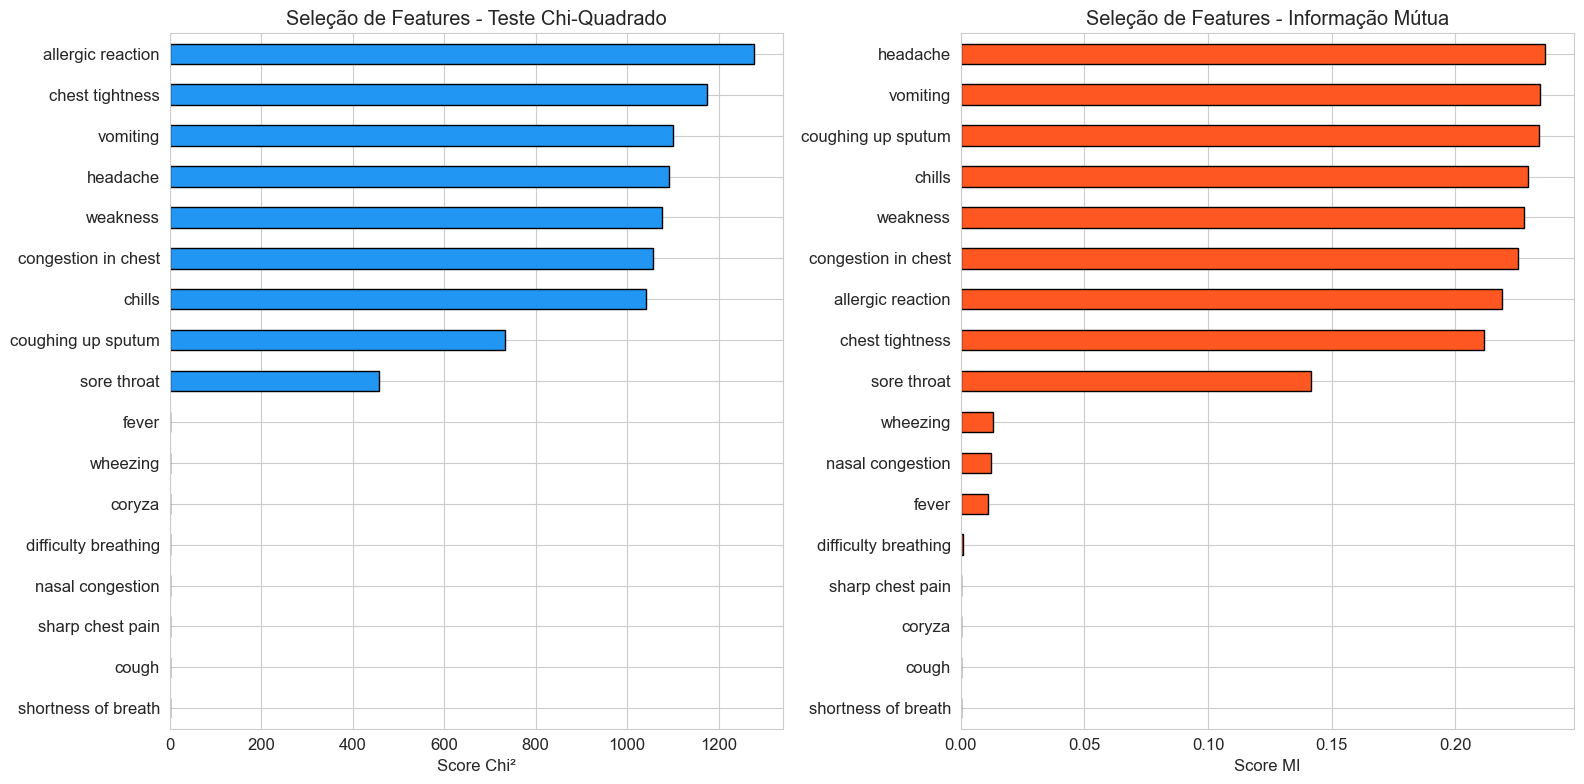


Comparação dos rankings de features:
                           Chi²  Info. Mútua
allergic reaction     1276.8805       0.2188
chest tightness       1174.9447       0.2116
chills                1041.0330       0.2295
congestion in chest   1057.1278       0.2251
coryza                   0.8641       0.0000
cough                    0.0270       0.0000
coughing up sputum     732.5401       0.2338
difficulty breathing     0.6897       0.0009
fever                    1.2663       0.0110
headache              1092.0165       0.2361
nasal congestion         0.2945       0.0123
sharp chest pain         0.0372       0.0000
shortness of breath      0.0012       0.0000
sore throat            457.0955       0.1418
vomiting              1100.4208       0.2341
weakness              1075.9670       0.2276
wheezing                 0.9509       0.0131


In [7]:
# Codificar variável-alvo
le = LabelEncoder()
y_codificado = le.fit_transform(df['diseases'])
classes = le.classes_
classes_titulo = [c.title() for c in classes]
print(f'Classes: {dict(zip(range(len(classes)), classes_titulo))}')

# 4.1 Teste Chi-Quadrado
seletor_chi2 = SelectKBest(chi2, k='all')
seletor_chi2.fit(X, y_codificado)
scores_chi2 = pd.Series(seletor_chi2.scores_, index=X.columns).sort_values(ascending=False)

# 4.2 Informação Mútua
scores_mi = pd.Series(
    mutual_info_classif(X, y_codificado, random_state=42),
    index=X.columns
).sort_values(ascending=False)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
scores_chi2.plot(kind='barh', color='#2196F3', edgecolor='black', ax=axes[0])
axes[0].set_title('Seleção de Features - Teste Chi-Quadrado')
axes[0].set_xlabel('Score Chi²'); axes[0].invert_yaxis()
scores_mi.plot(kind='barh', color='#FF5722', edgecolor='black', ax=axes[1])
axes[1].set_title('Seleção de Features - Informação Mútua')
axes[1].set_xlabel('Score MI'); axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Tabela comparativa
print('\nComparação dos rankings de features:')
comparacao = pd.DataFrame({'Chi²': scores_chi2, 'Info. Mútua': scores_mi})
print(comparacao.round(4).to_string())

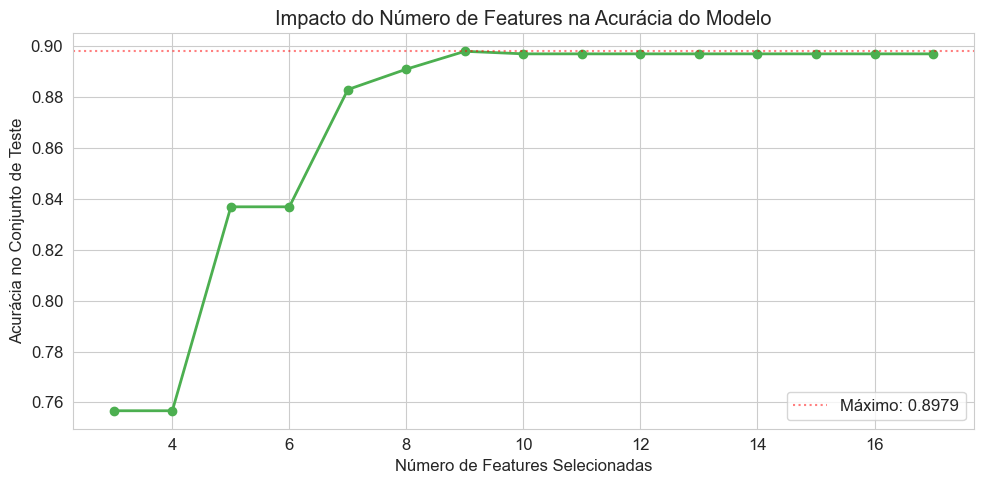

Total de features disponíveis: 17
Melhor quantidade de features pelo experimento: 9
Features selecionadas para modelagem: 9

Features selecionadas:
   1. chest tightness
   2. sore throat
   3. vomiting
   4. headache
   5. weakness
   6. chills
   7. coughing up sputum
   8. allergic reaction
   9. congestion in chest


In [8]:
# 4.3 Impacto do número de features na acurácia
n_total_features = X.shape[1]
k_valores = list(range(3, n_total_features + 1))
acuracias = []

for k in k_valores:
    sel_k = SelectKBest(chi2, k=k)
    X_k = sel_k.fit_transform(X, y_codificado)
    Xtr, Xte, ytr, yte = train_test_split(X_k, y_codificado, test_size=0.3,
                                           random_state=42, stratify=y_codificado)
    clf = DecisionTreeClassifier(max_depth=10, random_state=42)
    clf.fit(Xtr, ytr)
    acuracias.append(accuracy_score(yte, clf.predict(Xte)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_valores, acuracias, 'o-', color='#4CAF50', linewidth=2)
ax.set_xlabel('Número de Features Selecionadas')
ax.set_ylabel('Acurácia no Conjunto de Teste')
ax.set_title('Impacto do Número de Features na Acurácia do Modelo')
ax.axhline(y=max(acuracias), color='red', linestyle=':', alpha=0.5,
           label=f'Máximo: {max(acuracias):.4f}')
ax.legend()
plt.tight_layout()
plt.show()

# Selecionar automaticamente o melhor subconjunto de features pelo teste Chi-Quadrado
k_melhor = k_valores[int(np.argmax(acuracias))]
seletor_final = SelectKBest(chi2, k=k_melhor)
seletor_final.fit(X, y_codificado)
features_selecionadas = X.columns[seletor_final.get_support()].tolist()

print(f'Total de features disponíveis: {n_total_features}')
print(f'Melhor quantidade de features pelo experimento: {k_melhor}')
print(f'Features selecionadas para modelagem: {len(features_selecionadas)}')
print('\nFeatures selecionadas:')
for i, feature in enumerate(features_selecionadas, start=1):
    print(f'  {i:2d}. {feature}')

## 6. Modelagem e Avaliação

Quatro modelos foram implementados e comparados para evitar uma escolha sem justificativa experimental:
- **Árvore de Decisão** — modelo interpretável, bom para dados binários e útil para entender regras de decisão
- **Random Forest** — ensemble de árvores, reduz a variância de uma árvore isolada e permite analisar importância das features
- **Regressão Logística** — modelo linear robusto, adequado como baseline para classificação multiclasse
- **Rede Neural (MLP)** — modelo não-linear, capaz de capturar combinações mais complexas entre sintomas

**Divisão dos dados:** 70% treino (2.330 amostras) / 30% teste (999 amostras) com estratificação.

**Métricas utilizadas:** matriz de confusão, acurácia, precisão, recall, F1-Score e validação cruzada estratificada com 5 folds. Essas métricas são adequadas ao problema porque se trata de uma classificação multiclasse.

**Critério de escolha do melhor modelo:** o F1-Score ponderado foi usado como principal critério porque combina precisão e recall, sendo mais informativo que olhar apenas a acurácia.

In [9]:
# Preparar dados
X_final = df[features_selecionadas]
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_final, y_codificado, test_size=0.3, random_state=42, stratify=y_codificado
)
print(f'Conjunto de treino: {X_treino.shape[0]} amostras')
print(f'Conjunto de teste:  {X_teste.shape[0]} amostras')
print(f'Features utilizadas: {len(features_selecionadas)}')

# Definir modelos
modelos = {
    'Árvore de Decisão': DecisionTreeClassifier(
        max_depth=10, random_state=42, min_samples_leaf=5
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
    ),
    'Regressão Logística': LogisticRegression(
        max_iter=1000, random_state=42, C=1.0
    ),
    'Rede Neural (MLP)': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        random_state=42, early_stopping=True
    ),
}

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Treinar e avaliar cada modelo
resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_teste)
    cv_scores = cross_val_score(modelo, X_final, y_codificado, cv=cv, scoring='accuracy')
    
    resultados[nome] = {
        'modelo': modelo, 'y_pred': y_pred,
        'acuracia': accuracy_score(y_teste, y_pred),
        'precisao': precision_score(y_teste, y_pred, average='weighted'),
        'recall': recall_score(y_teste, y_pred, average='weighted'),
        'f1': f1_score(y_teste, y_pred, average='weighted'),
        'cv_media': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'matriz_confusao': confusion_matrix(y_teste, y_pred),
    }
    
    print(f'\n{"=" * 50}')
    print(f'{nome}')
    print(f'{"=" * 50}')
    print(f'  Acurácia:  {resultados[nome]["acuracia"]:.4f}')
    print(f'  Precisão:  {resultados[nome]["precisao"]:.4f}')
    print(f'  Recall:    {resultados[nome]["recall"]:.4f}')
    print(f'  F1-Score:  {resultados[nome]["f1"]:.4f}')
    print(f'  CV 5-fold: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'\n{classification_report(y_teste, y_pred, target_names=classes_titulo)}')

Conjunto de treino: 2330 amostras
Conjunto de teste:  999 amostras
Features utilizadas: 9

Árvore de Decisão
  Acurácia:  0.8979
  Precisão:  0.9129
  Recall:    0.8979
  F1-Score:  0.8994
  CV 5-fold: 0.9006 ± 0.0091

                  precision    recall  f1-score   support

Acute Bronchitis       0.93      0.86      0.89       364
          Asthma       0.78      1.00      0.88       271
       Pneumonia       1.00      0.86      0.93       364

        accuracy                           0.90       999
       macro avg       0.90      0.91      0.90       999
    weighted avg       0.91      0.90      0.90       999




Random Forest
  Acurácia:  0.9029
  Precisão:  0.9197
  Recall:    0.9029
  F1-Score:  0.9036
  CV 5-fold: 0.9006 ± 0.0091

                  precision    recall  f1-score   support

Acute Bronchitis       1.00      0.80      0.89       364
          Asthma       0.78      1.00      0.88       271
       Pneumonia       0.94      0.93      0.94       364

        accuracy                           0.90       999
       macro avg       0.91      0.91      0.90       999
    weighted avg       0.92      0.90      0.90       999


Regressão Logística
  Acurácia:  0.8979
  Precisão:  0.9129
  Recall:    0.8979
  F1-Score:  0.8994
  CV 5-fold: 0.9018 ± 0.0107

                  precision    recall  f1-score   support

Acute Bronchitis       0.93      0.86      0.89       364
          Asthma       0.78      1.00      0.88       271
       Pneumonia       1.00      0.86      0.93       364

        accuracy                           0.90       999
       macro avg       0.90      0.91      


Rede Neural (MLP)
  Acurácia:  0.8979
  Precisão:  0.9129
  Recall:    0.8979
  F1-Score:  0.8994
  CV 5-fold: 0.9012 ± 0.0105

                  precision    recall  f1-score   support

Acute Bronchitis       0.93      0.86      0.89       364
          Asthma       0.78      1.00      0.88       271
       Pneumonia       1.00      0.86      0.93       364

        accuracy                           0.90       999
       macro avg       0.90      0.91      0.90       999
    weighted avg       0.91      0.90      0.90       999



## 7. Matrizes de Confusão

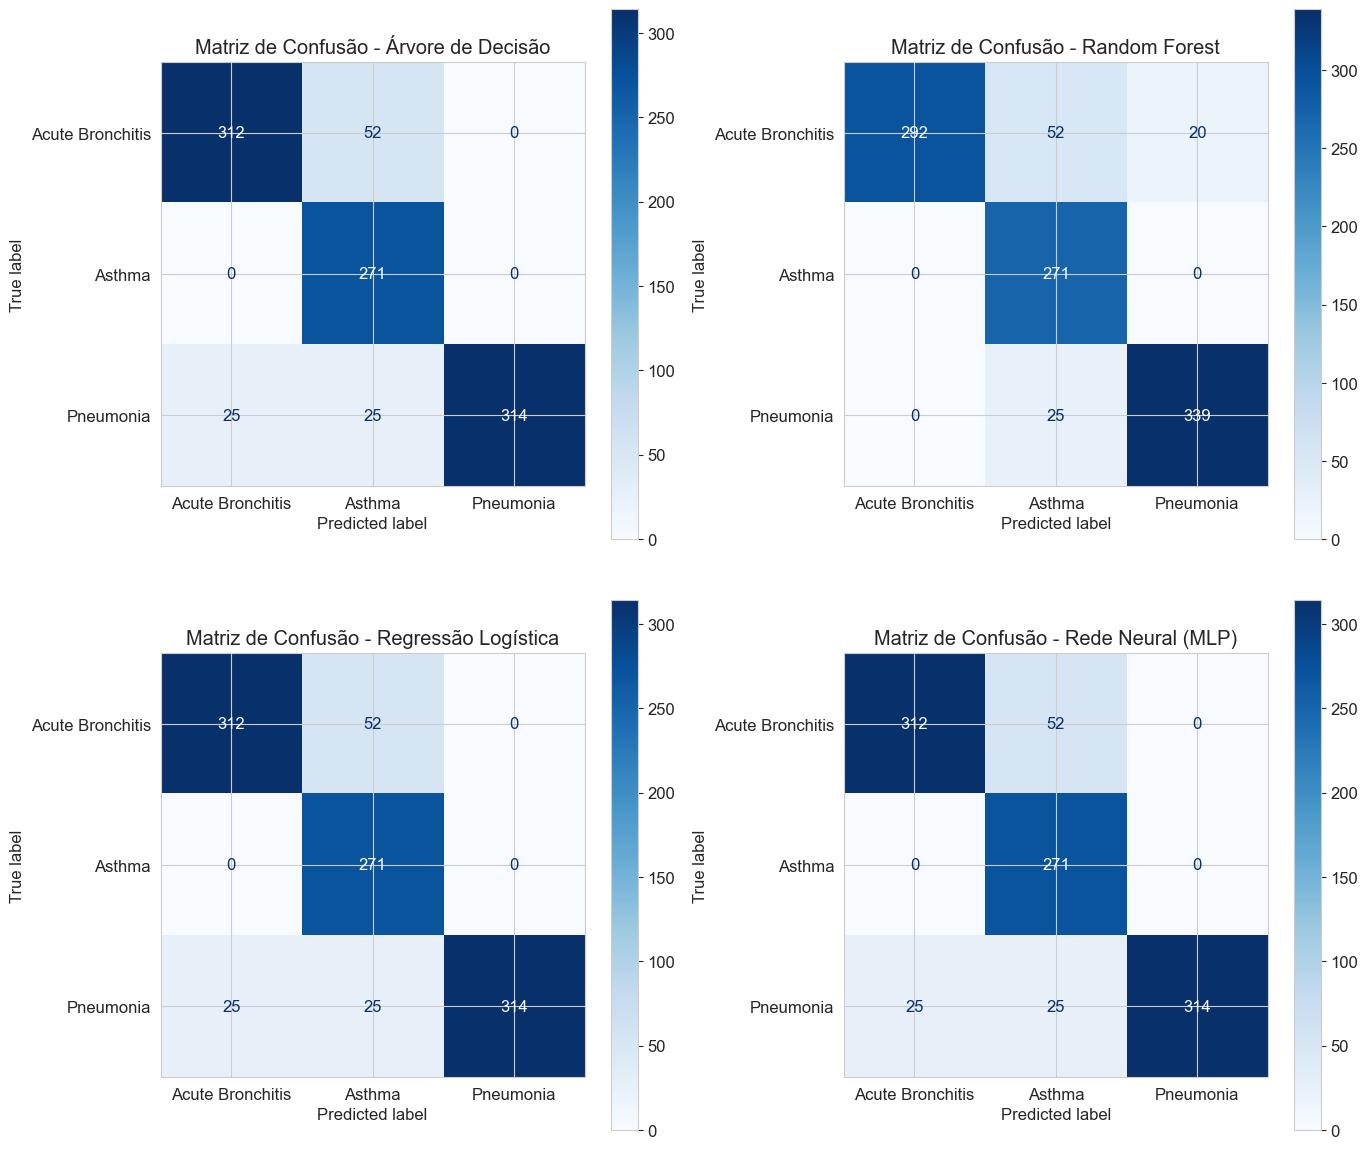

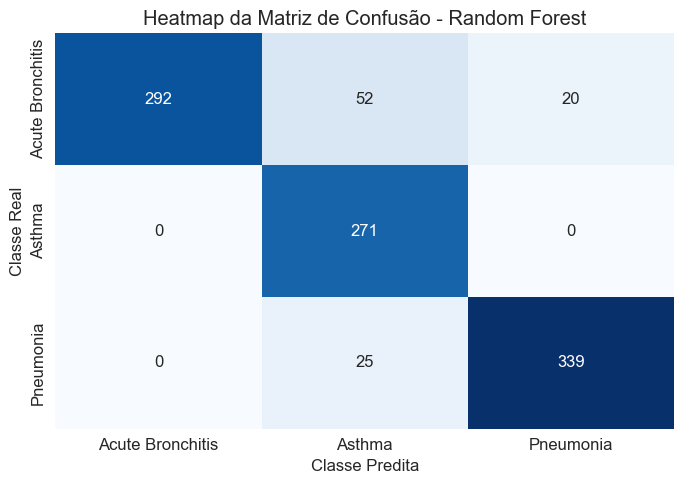

### Análise da Matriz de Confusão - Random Forest

,Classe real,Total,Acertos,Erros,Recall da classe,Principal confusão,Quantidade
0,Acute Bronchitis,364,292,72,0.802198,Asthma,52
1,Asthma,271,271,0,1.000000,Sem erro,0
2,Pneumonia,364,339,25,0.931319,Asthma,25


A classe com mais erros foi **Acute Bronchitis**, principalmente confundida com **Asthma** (52 casos). Isso indica que o maior desafio do modelo está nas doenças com sintomas respiratórios sobrepostos.

In [10]:
from IPython.display import Markdown, display

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (nome, res) in zip(axes.flatten(), resultados.items()):
    ConfusionMatrixDisplay(
        res['matriz_confusao'], display_labels=classes_titulo
    ).plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Matriz de Confusão - {nome}')
plt.tight_layout()
plt.show()

# Heatmap e análise detalhada dos erros do melhor modelo pelo F1-Score
melhor_nome_confusao = max(resultados, key=lambda nome: resultados[nome]['f1'])
matriz_melhor = resultados[melhor_nome_confusao]['matriz_confusao']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    matriz_melhor, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=classes_titulo, yticklabels=classes_titulo, ax=ax
)
ax.set_title(f'Heatmap da Matriz de Confusão - {melhor_nome_confusao}')
ax.set_xlabel('Classe Predita')
ax.set_ylabel('Classe Real')
plt.tight_layout()
plt.show()

analise_erros = []
for i, classe_real in enumerate(classes_titulo):
    total_classe = matriz_melhor[i].sum()
    acertos = matriz_melhor[i, i]
    erros = total_classe - acertos
    destinos_erro = [
        (classes_titulo[j], matriz_melhor[i, j])
        for j in range(len(classes_titulo))
        if j != i and matriz_melhor[i, j] > 0
    ]
    principal_confusao = max(destinos_erro, key=lambda item: item[1]) if destinos_erro else ('Sem erro', 0)
    analise_erros.append({
        'Classe real': classe_real,
        'Total': total_classe,
        'Acertos': acertos,
        'Erros': erros,
        'Recall da classe': acertos / total_classe,
        'Principal confusão': principal_confusao[0],
        'Quantidade': principal_confusao[1],
    })

df_analise_erros = pd.DataFrame(analise_erros)
display(Markdown(f'### Análise da Matriz de Confusão - {melhor_nome_confusao}'))
display(df_analise_erros)

maior_erro = df_analise_erros.sort_values('Erros', ascending=False).iloc[0]
display(Markdown(
    f"A classe com mais erros foi **{maior_erro['Classe real']}**, "
    f"principalmente confundida com **{maior_erro['Principal confusão']}** "
    f"({int(maior_erro['Quantidade'])} casos). Isso indica que o maior desafio do modelo "
    "está nas doenças com sintomas respiratórios sobrepostos."
))

## 8. Comparação de Métricas entre Modelos

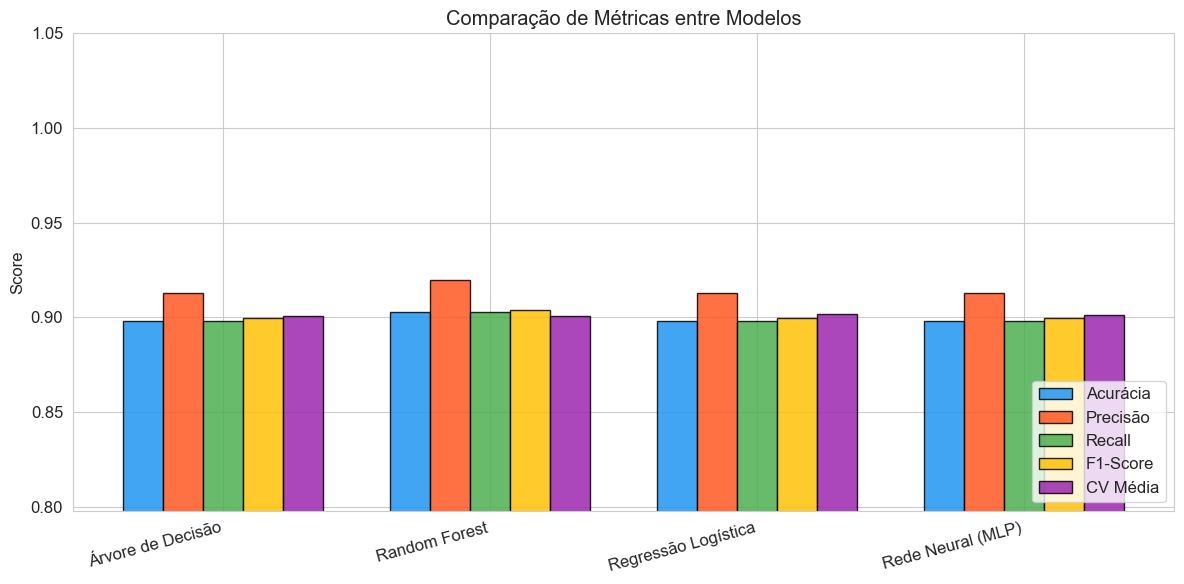

Tabela de Resultados Consolidados:
                     Acurácia  Precisão  Recall  F1-Score  CV Média
Árvore de Decisão      0.8979    0.9129  0.8979    0.8994    0.9006
Random Forest          0.9029    0.9197  0.9029    0.9036    0.9006
Regressão Logística    0.8979    0.9129  0.8979    0.8994    0.9018
Rede Neural (MLP)      0.8979    0.9129  0.8979    0.8994    0.9012

Melhor modelo (F1-Score): Random Forest


In [11]:
# Tabela consolidada de métricas
tabela_metricas = pd.DataFrame({
    nome: {
        'Acurácia': r['acuracia'],
        'Precisão': r['precisao'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'CV Média': r['cv_media'],
    }
    for nome, r in resultados.items()
}).T
tabela_metricas.to_csv('metricas_resultados.csv')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(tabela_metricas))
largura = 0.15
cores_metricas = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107', '#9C27B0']
for i, col in enumerate(tabela_metricas.columns):
    ax.bar(x + i * largura, tabela_metricas[col], largura,
           label=col, color=cores_metricas[i], edgecolor='black', alpha=0.85)
ax.set_xticks(x + largura * 2)
ax.set_xticklabels(tabela_metricas.index, rotation=15, ha='right')
ax.set_ylabel('Score'); ax.set_title('Comparação de Métricas entre Modelos')
ax.legend(loc='lower right')
ax.set_ylim(max(0, tabela_metricas.min().min() - 0.1), 1.05)
plt.tight_layout()
plt.show()

print('Tabela de Resultados Consolidados:')
print(tabela_metricas.round(4).to_string())
print(f'\nMelhor modelo (F1-Score): {tabela_metricas["F1-Score"].idxmax()}')

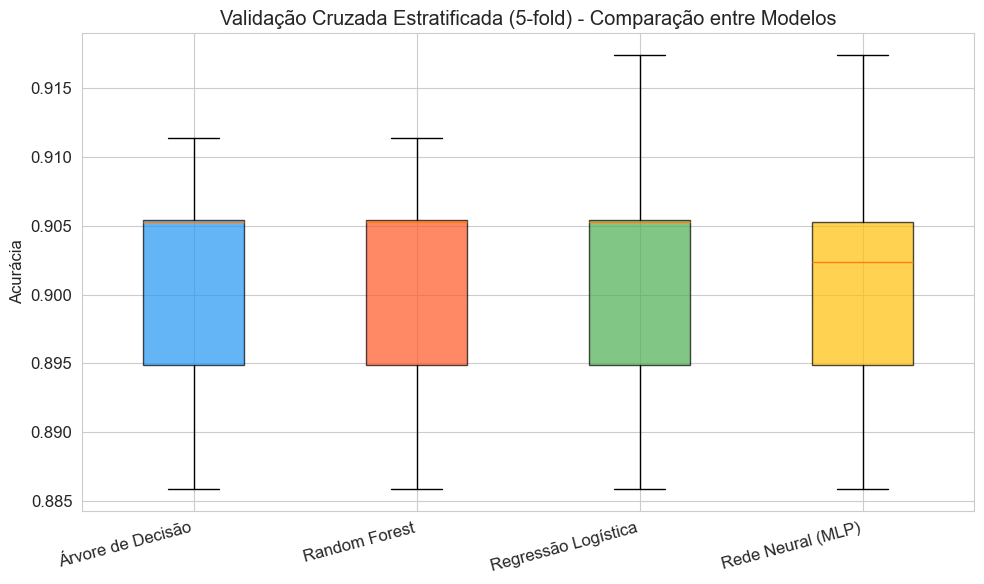

In [12]:
# Validação Cruzada - Boxplot
fig, ax = plt.subplots(figsize=(10, 6))
dados_cv = [cross_val_score(m, X_final, y_codificado, cv=cv, scoring='accuracy')
            for m in modelos.values()]
bp = ax.boxplot(dados_cv, labels=list(modelos.keys()), patch_artist=True)
cores_box = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor); patch.set_alpha(0.7)
ax.set_ylabel('Acurácia')
ax.set_title('Validação Cruzada Estratificada (5-fold) - Comparação entre Modelos')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 9. Interpretabilidade dos Modelos

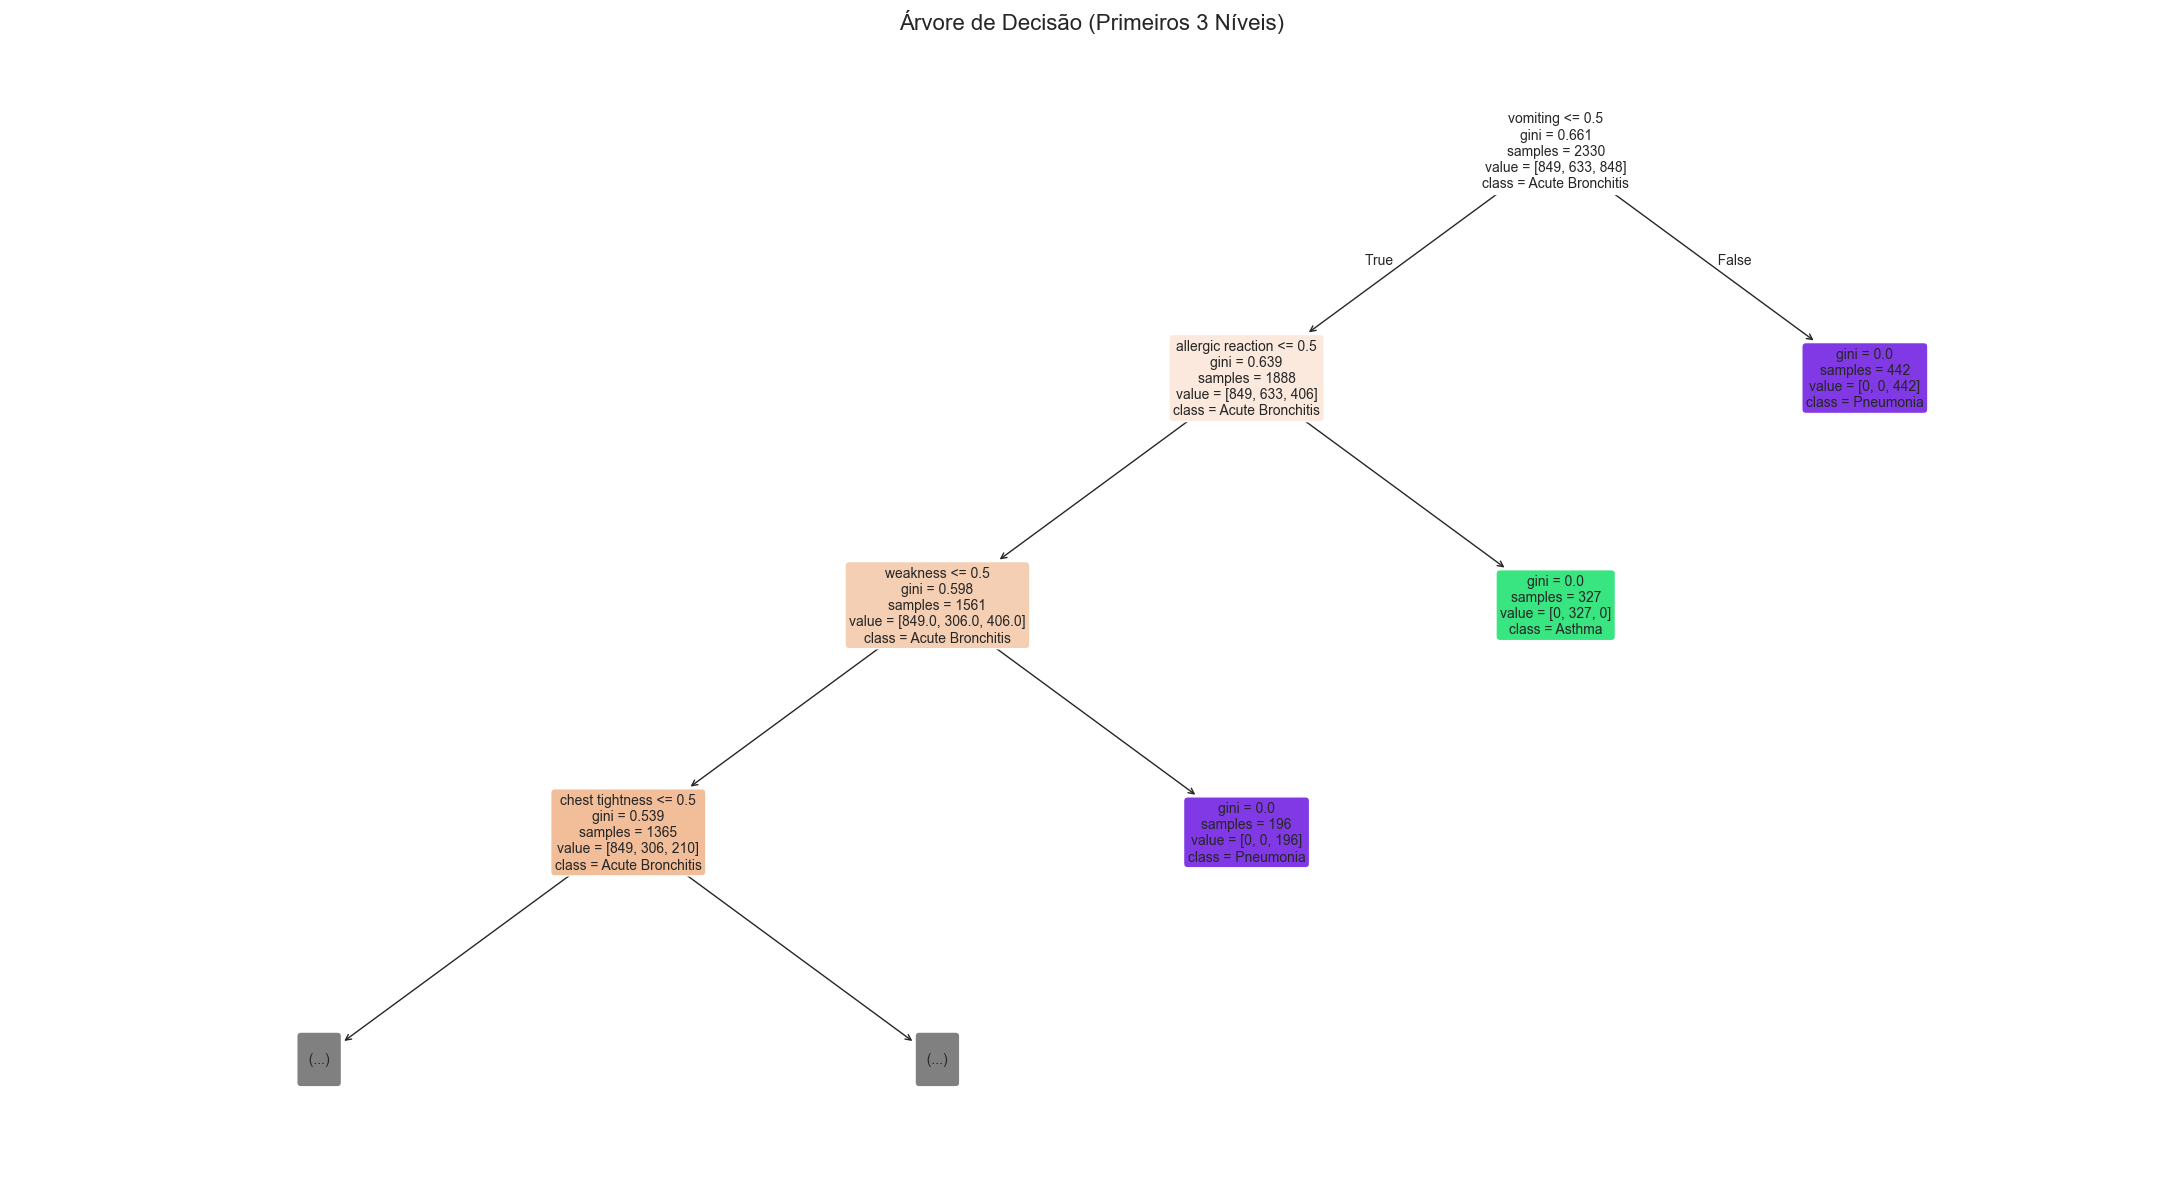

In [13]:
# 8.1 Visualização da Árvore de Decisão (primeiros 3 níveis)
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(
    resultados['Árvore de Decisão']['modelo'],
    feature_names=features_selecionadas,
    class_names=classes_titulo,
    filled=True, rounded=True, ax=ax,
    max_depth=3, fontsize=10
)
ax.set_title('Árvore de Decisão (Primeiros 3 Níveis)', fontsize=16)
plt.tight_layout()
plt.show()

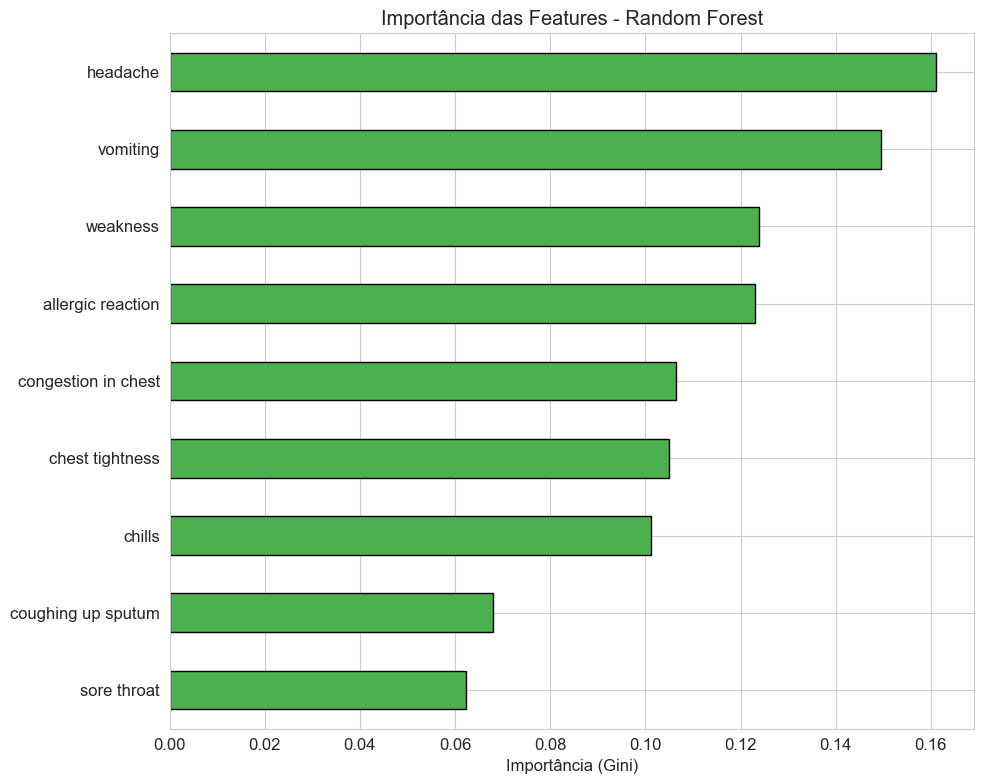

Ranking de importância das features (Random Forest):
   1. headache                            0.1610
   2. vomiting                            0.1495
   3. weakness                            0.1238
   4. allergic reaction                   0.1230
   5. congestion in chest                 0.1064
   6. chest tightness                     0.1049
   7. chills                              0.1011
   8. coughing up sputum                  0.0679
   9. sore throat                         0.0623


In [14]:
# 8.2 Importância das Features - Random Forest
rf = resultados['Random Forest']['modelo']
importancias = pd.Series(
    rf.feature_importances_, index=features_selecionadas
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importancias.plot(kind='barh', color='#4CAF50', edgecolor='black', ax=ax)
ax.set_title('Importância das Features - Random Forest')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()

print('Ranking de importância das features (Random Forest):')
for i, (feat, imp) in enumerate(importancias.sort_values(ascending=False).items()):
    print(f'  {i+1:2d}. {feat:35s} {imp:.4f}')

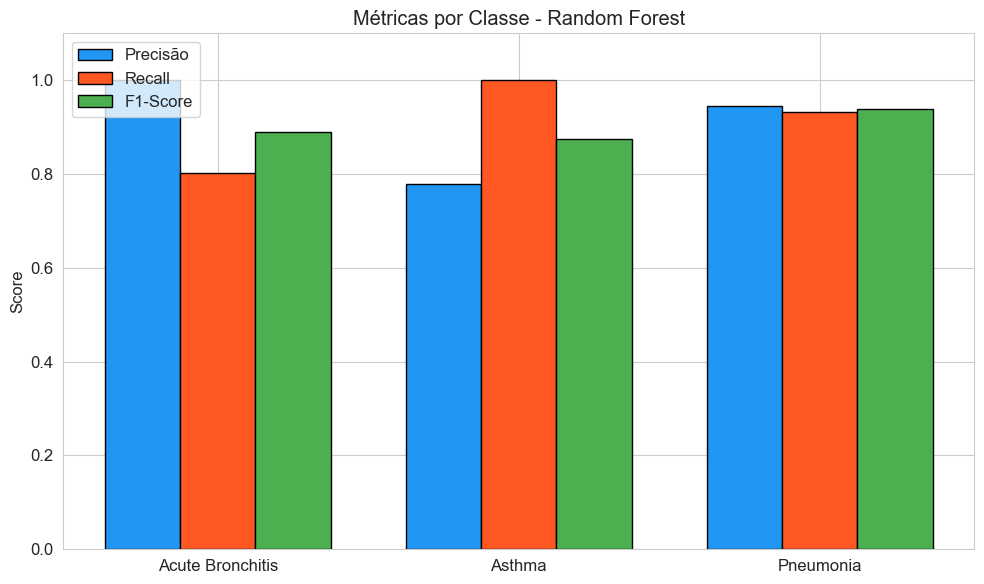


Métricas detalhadas por classe (Random Forest):
  Acute Bronchitis     Precisão=1.000  Recall=0.802  F1=0.890
  Asthma               Precisão=0.779  Recall=1.000  F1=0.876
  Pneumonia            Precisão=0.944  Recall=0.931  F1=0.938


In [15]:
# 8.3 Métricas por classe do melhor modelo
melhor_nome = tabela_metricas['F1-Score'].idxmax()
y_pred_melhor = resultados[melhor_nome]['y_pred']

prec_classe = precision_score(y_teste, y_pred_melhor, average=None)
rec_classe = recall_score(y_teste, y_pred_melhor, average=None)
f1_classe = f1_score(y_teste, y_pred_melhor, average=None)

fig, ax = plt.subplots(figsize=(10, 6))
x_c = np.arange(len(classes_titulo)); w = 0.25
ax.bar(x_c - w, prec_classe, w, label='Precisão', color='#2196F3', edgecolor='black')
ax.bar(x_c, rec_classe, w, label='Recall', color='#FF5722', edgecolor='black')
ax.bar(x_c + w, f1_classe, w, label='F1-Score', color='#4CAF50', edgecolor='black')
ax.set_xticks(x_c); ax.set_xticklabels(classes_titulo)
ax.set_ylabel('Score'); ax.set_title(f'Métricas por Classe - {melhor_nome}')
ax.legend(); ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print(f'\nMétricas detalhadas por classe ({melhor_nome}):')
for i, c in enumerate(classes_titulo):
    print(f'  {c:20s} Precisão={prec_classe[i]:.3f}  Recall={rec_classe[i]:.3f}  F1={f1_classe[i]:.3f}')

## 10. Conclusão e Trabalhos Futuros

A tabela e as conclusões abaixo são geradas automaticamente pelo Jupyter a partir dos resultados calculados nas células anteriores.

In [16]:
from IPython.display import Markdown, display

def percentual(valor):
    return f'{valor * 100:.2f}%'.replace('.', ',')

def decimal_br(valor, casas=4):
    return f'{valor:.{casas}f}'.replace('.', ',')

def inteiro_br(valor):
    return f'{valor:,}'.replace(',', '.')

tabela_conclusao = tabela_metricas.rename(columns={'CV Média': 'CV (5-fold)'})
tabela_conclusao = tabela_conclusao.apply(lambda coluna: coluna.map(percentual))

melhor_modelo = tabela_metricas['F1-Score'].idxmax()
modelo_cv = tabela_metricas['CV Média'].idxmax()
metricas_melhor = tabela_metricas.loc[melhor_modelo]
k_melhor = k_valores[int(np.argmax(acuracias))]
top_features = importancias.sort_values(ascending=False).head(6).index.tolist()
top_features_txt = ', '.join(top_features)

nomes_pt = {
    'Acute Bronchitis': 'Bronquite Aguda',
    'Asthma': 'Asma',
    'Pneumonia': 'Pneumonia',
}
f1_classes_txt = ', '.join(
    f'{nomes_pt.get(classe, classe)}: {decimal_br(f1_classe[i], 3)}'
    for i, classe in enumerate(classes_titulo)
)

display(Markdown('### Resultados Consolidados'))
display(tabela_conclusao)

conclusoes = f'''
### Principais Conclusões

1. **Dataset real do Kaggle**: {inteiro_br(df_full.shape[0])} amostras originais filtradas para {inteiro_br(df.shape[0])} amostras das três doenças respiratórias escolhidas.
2. **Redução dimensional expressiva**: de {df_full.shape[1] - 1} sintomas originais, {n_total_features} sintomas permaneceram após remover colunas sem variância.
3. **Seleção de features aplicada**: o SelectKBest selecionou {len(features_selecionadas)} sintomas para a modelagem final, quantidade que apresentou o melhor desempenho no experimento com árvore de decisão.
4. **Melhor modelo geral**: {melhor_modelo} obteve o maior F1-Score ({decimal_br(metricas_melhor['F1-Score'])}) e a maior acurácia ({percentual(metricas_melhor['Acurácia'])}) no conjunto de teste.
5. **Modelo mais estável na validação cruzada**: {modelo_cv} apresentou a maior média de CV 5-fold ({percentual(tabela_metricas.loc[modelo_cv, 'CV Média'])}).
6. **Sintomas mais importantes no Random Forest**: {top_features_txt} apareceram entre os atributos com maior importância.
7. **Métricas por classe do melhor modelo**: {f1_classes_txt}.
8. O principal desafio está na **sobreposição de sintomas respiratórios**, especialmente entre doenças que compartilham tosse, falta de ar, congestão e sintomas sistêmicos.
9. O limite de performance está relacionado à **natureza binária e simplificada dos dados**, pois sintomas isolados nem sempre são suficientes para distinguir doenças clinicamente semelhantes.
'''

display(Markdown(conclusoes))

### Resultados Consolidados

,Acurácia,Precisão,Recall,F1-Score,CV (5-fold)
Árvore de Decisão,"89,79%","91,29%","89,79%","89,94%","90,06%"
Random Forest,"90,29%","91,97%","90,29%","90,36%","90,06%"
Regressão Logística,"89,79%","91,29%","89,79%","89,94%","90,18%"
Rede Neural (MLP),"89,79%","91,29%","89,79%","89,94%","90,12%"



### Principais Conclusões

1. **Dataset real do Kaggle**: 246.945 amostras originais filtradas para 3.329 amostras das três doenças respiratórias escolhidas.
2. **Redução dimensional expressiva**: de 377 sintomas originais, 17 sintomas permaneceram após remover colunas sem variância.
3. **Seleção de features aplicada**: o SelectKBest selecionou 9 sintomas para a modelagem final, quantidade que apresentou o melhor desempenho no experimento com árvore de decisão.
4. **Melhor modelo geral**: Random Forest obteve o maior F1-Score (0,9036) e a maior acurácia (90,29%) no conjunto de teste.
5. **Modelo mais estável na validação cruzada**: Regressão Logística apresentou a maior média de CV 5-fold (90,18%).
6. **Sintomas mais importantes no Random Forest**: headache, vomiting, weakness, allergic reaction, congestion in chest, chest tightness apareceram entre os atributos com maior importância.
7. **Métricas por classe do melhor modelo**: Bronquite Aguda: 0,890, Asma: 0,876, Pneumonia: 0,938.
8. O principal desafio está na **sobreposição de sintomas respiratórios**, especialmente entre doenças que compartilham tosse, falta de ar, congestão e sintomas sistêmicos.
9. O limite de performance está relacionado à **natureza binária e simplificada dos dados**, pois sintomas isolados nem sempre são suficientes para distinguir doenças clinicamente semelhantes.


### Trabalhos Futuros

- Incluir variáveis numéricas (temperatura, frequência cardíaca)
- Aplicar Grid Search para otimização de hiperparâmetros
- Validar com dados clínicos reais em ambiente hospitalar
- Expandir para mais doenças respiratórias

## Referências

- DHIVYESH RK. **Diseases and Symptoms Dataset**. Kaggle. Disponível em: https://www.kaggle.com/datasets/dhivyeshrk/diseases-and-symptoms-dataset.
- PEDREGOSA, F. et al. **Scikit-learn: Machine Learning in Python**. Journal of Machine Learning Research, v. 12, p. 2825-2830, 2011.
- MCKINNEY, W. **Data Structures for Statistical Computing in Python**. Proceedings of the 9th Python in Science Conference, 2010.
- HUNTER, J. D. **Matplotlib: A 2D Graphics Environment**. Computing in Science & Engineering, v. 9, n. 3, p. 90-95, 2007.
- KLUYVER, T. et al. **Jupyter Notebooks: a publishing format for reproducible computational workflows**. Positioning and Power in Academic Publishing, 2016.

---
*Todo o trabalho foi desenvolvido em Jupyter Notebook utilizando Python, Scikit-learn, Pandas, Matplotlib e Seaborn.*